In [83]:
%pip install torch torchvision --quiet
%pip install ftfy regex tqdm --quiet
%pip install matplotlib --quiet
%pip install git+https://github.com/openai/CLIP.git --quiet

import torch
import clip
from PIL import Image
from IPython.display import display
import glob
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
from collections import defaultdict



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [84]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)
print(f"Using device: {device}")


Using device: mps


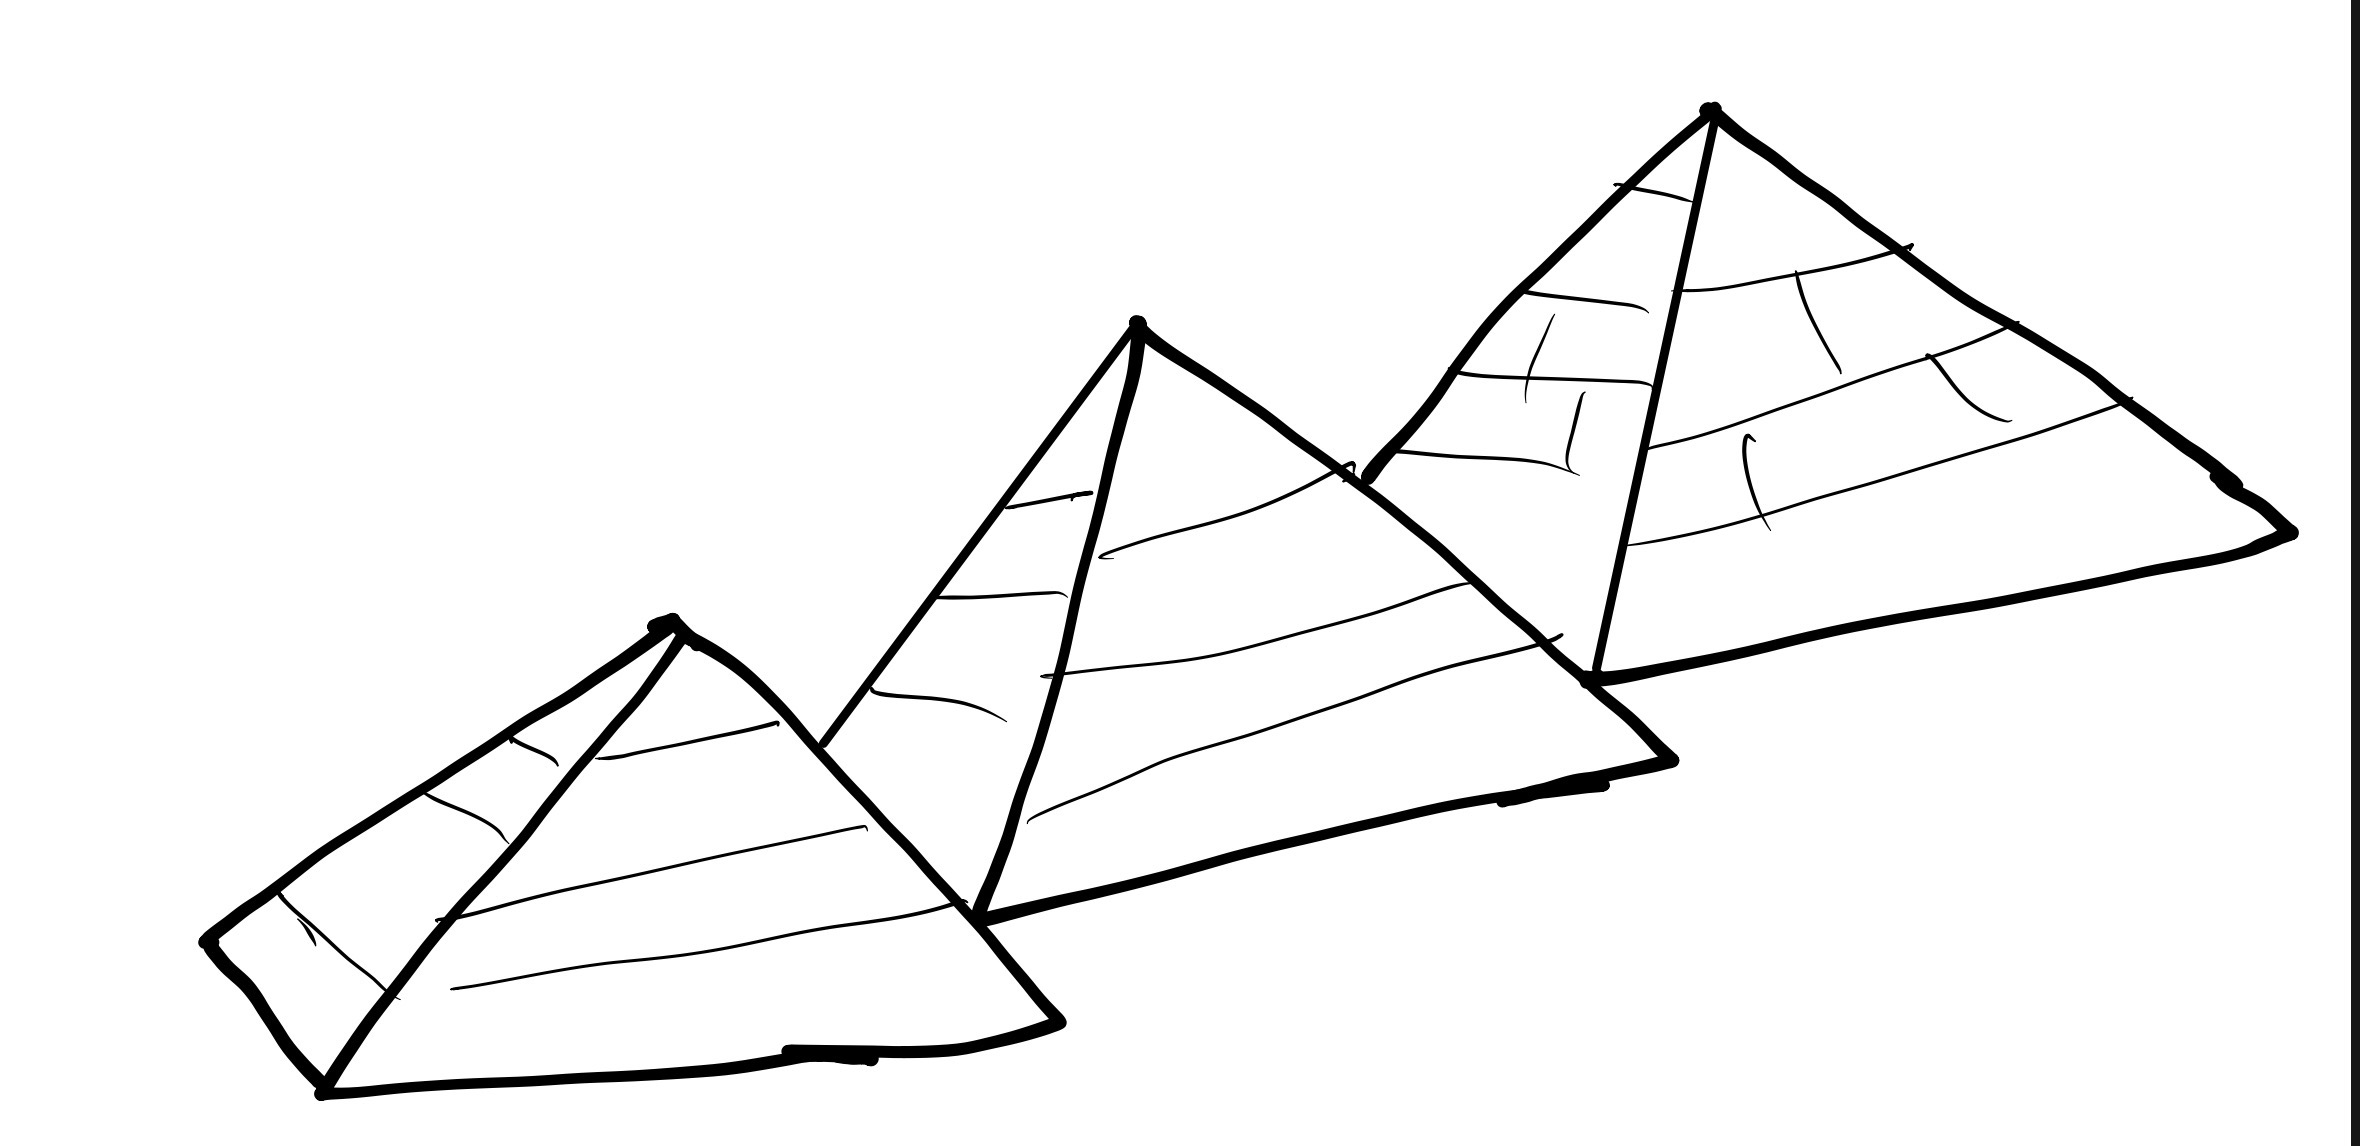

In [85]:
# Update this path to point to your sketch image
sketch_path = "pyramid-mid.jpg"

# Or choose a V0 sketch file, e.g. "sketch1.png" or "sketch2.png"
display(Image.open(sketch_path))


In [86]:
# Zero-shot classification: what does the sketch depict?
image_input = preprocess(Image.open(sketch_path)).unsqueeze(0).to(device)

text_labels = [
    "a pyramid",
    "a mosque",
    "a temple",
    "a palace",
    "a bridge",
    "a museum",
    "a beach",
    "a stadium",
]
text_tokens = clip.tokenize(text_labels).to(device)

with torch.no_grad():
    logits_per_image, _ = model(image_input, text_tokens)
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()

for label, prob in zip(text_labels, probs[0]):
    print(f"  {label}: {prob:.4f}")


  a pyramid: 0.9990
  a mosque: 0.0000
  a temple: 0.0003
  a palace: 0.0002
  a bridge: 0.0001
  a museum: 0.0001
  a beach: 0.0001
  a stadium: 0.0000


In [87]:
image_paths = glob.glob("dataset/images/*/*.jpg")
print("Number of images found:", len(image_paths))
assert image_paths, "No images found! Check the dataset/images/ path."

image_features_list = []

for path in image_paths:
    img = preprocess(Image.open(path)).unsqueeze(0).to(device)

    with torch.no_grad():
        features = model.encode_image(img)
        features /= features.norm(dim=-1, keepdim=True)

    image_features_list.append(features)

image_features = torch.cat(image_features_list)
print("Image feature shape:", image_features.shape)


Number of images found: 5399
Image feature shape: torch.Size([5399, 512])


In [88]:
os.makedirs("embeddings", exist_ok=True)

torch.save(image_features, "embeddings/image_features.pt")

with open("embeddings/image_paths.pkl", "wb") as f:
    pickle.dump(image_paths, f)

print("Embeddings saved.")


Embeddings saved.


=== BEFORE filtering (raw retrieval) ===
  [1] Pyramid_of_Qakare_Ibi  score=0.8257
  [2] Pyramid_of_Userkaf  score=0.8052
  [3] Pyramid_of_Pepi_I  score=0.7871
  [4] Pyramid_of_Nyuserre_Ini  score=0.7812
  [5] Pyramid_of_Ameni_Qemau  score=0.7808


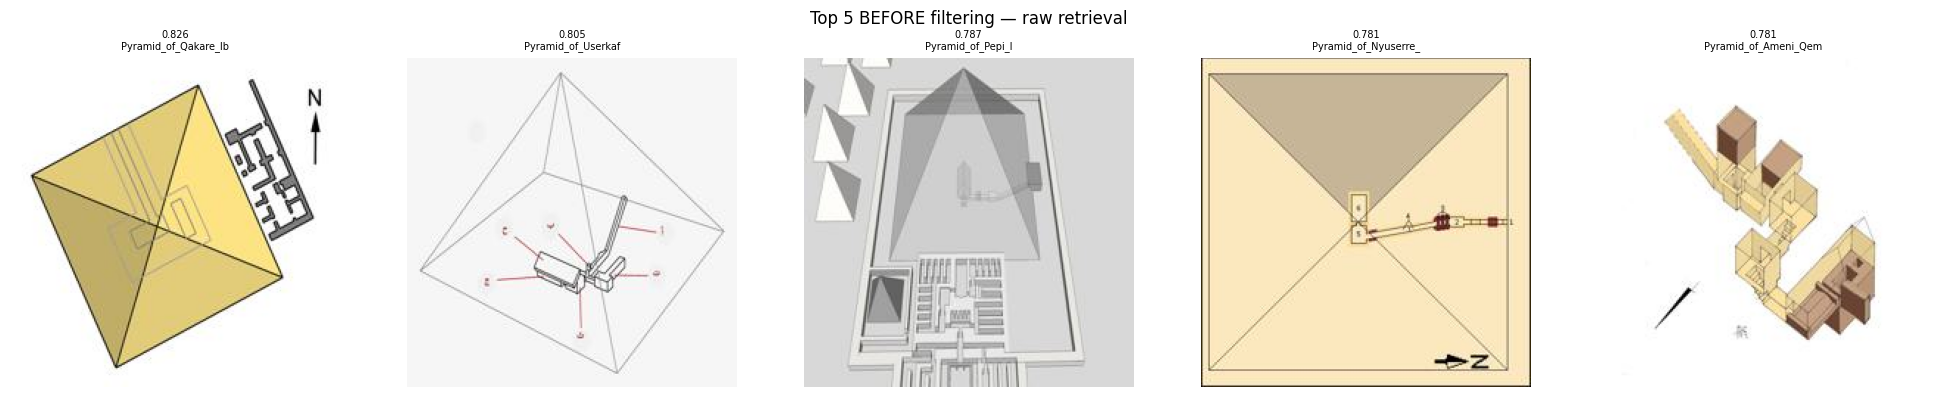


Removed 476 diagram-like images (8.8%)
Clean index: 4923 images
Saved → embeddings/image_features_clean.pt

=== AFTER filtering (clean retrieval) ===
  [1] Pyramid_of_Djedefra  score=0.7466
  [2] Pyramid_of_Neferirkare  score=0.7261
  [3] Giza_pyramid_complex  score=0.7261
  [4] Giza_pyramid_complex  score=0.7256
  [5] Giza_pyramid_complex  score=0.7251


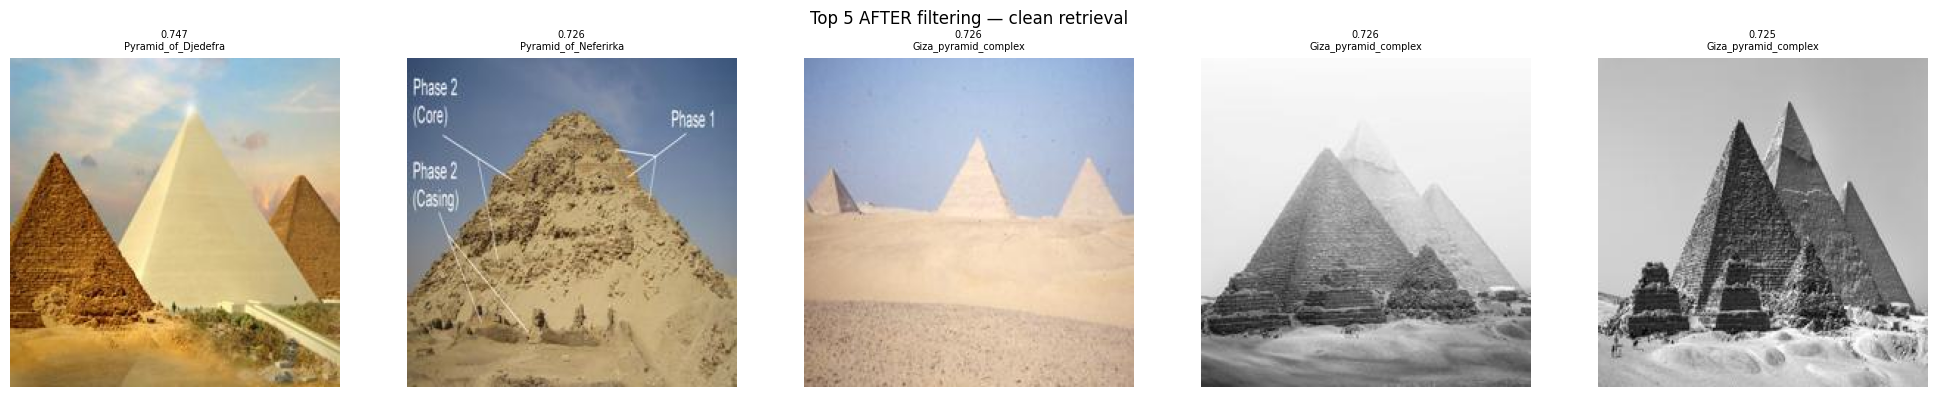

In [89]:
# Load raw embeddings
image_features = torch.load("embeddings/image_features.pt", weights_only=True).to(device)
with open("embeddings/image_paths.pkl", "rb") as f:
    image_paths = pickle.load(f)

# Encode query sketch
sketch = preprocess(Image.open(sketch_path)).unsqueeze(0).to(device)
with torch.no_grad():
    sketch_feat = model.encode_image(sketch)
    sketch_feat /= sketch_feat.norm(dim=-1, keepdim=True)

# --- BEFORE filtering ---
sims_raw = (sketch_feat @ image_features.T).cpu().numpy()
top_k = 5
top_raw = sims_raw.argsort()[0][-top_k:][::-1]

print("=== BEFORE filtering (raw retrieval) ===")
fig, axes = plt.subplots(1, top_k, figsize=(20, 4))
for i, idx in enumerate(top_raw):
    path = image_paths[idx]
    class_name = path.split("/")[-2]
    print(f"  [{i+1}] {class_name}  score={sims_raw[0][idx]:.4f}")
    try:
        axes[i].imshow(mpimg.imread(path))
        axes[i].set_title(f"{sims_raw[0][idx]:.3f}\n{class_name[:20]}", fontsize=7)
        axes[i].axis("off")
    except Exception:
        axes[i].axis("off")
plt.suptitle("Top 5 BEFORE filtering — raw retrieval", fontsize=12)
plt.tight_layout()
plt.show()

# --- Filter: remove diagrams ---
filter_texts = clip.tokenize([
    "a real photograph of a landmark or building",
    "an architectural diagram, floor plan, or technical drawing",
    "a 3D render or computer generated illustration",
]).to(device)

with torch.no_grad():
    filter_feats = model.encode_text(filter_texts)
    filter_feats /= filter_feats.norm(dim=-1, keepdim=True)
    scores = (image_features @ filter_feats.T)

keep_mask = scores[:, 0] > scores[:, 1:].max(dim=1).values
keep_indices = keep_mask.nonzero(as_tuple=True)[0].tolist()
filtered_features = image_features[keep_mask]
filtered_paths = [image_paths[i] for i in keep_indices]

removed = len(image_paths) - len(filtered_paths)
print(f"\nRemoved {removed} diagram-like images ({removed/len(image_paths)*100:.1f}%)")
print(f"Clean index: {len(filtered_paths)} images")

# Save clean index
torch.save(filtered_features.cpu(), "embeddings/image_features_clean.pt")
with open("embeddings/image_paths_clean.pkl", "wb") as f:
    pickle.dump(filtered_paths, f)
print("Saved → embeddings/image_features_clean.pt")

# --- AFTER filtering ---
sims_clean = (sketch_feat @ filtered_features.T).cpu().numpy()
top_clean = sims_clean.argsort()[0][-top_k:][::-1]

print("\n=== AFTER filtering (clean retrieval) ===")
fig, axes = plt.subplots(1, top_k, figsize=(20, 4))
for i, idx in enumerate(top_clean):
    path = filtered_paths[idx]
    class_name = path.split("/")[-2]
    print(f"  [{i+1}] {class_name}  score={sims_clean[0][idx]:.4f}")
    try:
        axes[i].imshow(mpimg.imread(path))
        axes[i].set_title(f"{sims_clean[0][idx]:.3f}\n{class_name[:20]}", fontsize=7)
        axes[i].axis("off")
    except Exception:
        axes[i].axis("off")
plt.suptitle("Top 5 AFTER filtering — clean retrieval", fontsize=12)
plt.tight_layout()
plt.show()
